# What Drives the Price of a Car?

**Author:** Adil Sameer   
**Dataset:** 426K used car listings (sourced from Kaggle)  
**Framework:** CRISP-DM

---

## Overview

This notebook explores a large dataset of used car listings to identify the key factors that drive used car prices. Using the CRISP-DM framework, we clean and prepare the data, engineer features, train multiple regression models, and translate findings into actionable recommendations for a used car dealership.


---
## 1. Business Understanding

### Business Problem
A used car dealership wants to understand which vehicle attributes most strongly influence resale price, so they can make smarter inventory decisions — stocking vehicles that sell at higher margins and faster.

### Data Problem Definition
We frame this as a **supervised regression problem**: predict the selling price of a used car from vehicle attributes (features). By training regularized linear regression models and inspecting their coefficients, we can quantify which factors most strongly drive price up or down.

### Evaluation Metric: MAE (Mean Absolute Error)
Our primary metric is **Mean Absolute Error (MAE)** — the average absolute difference between predicted and actual prices.

### Key Questions
1. Which vehicle attributes have the strongest effect on price?
2. How accurately can we predict used car prices from these attributes?
3. What inventory adjustments should the dealership make based on the findings?


---
## 2. Data Understanding


In [1]:
# ── Library Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
df_raw = pd.read_csv('vehicles.csv')
print(f'Dataset shape: {df_raw.shape}')
df_raw.head(5)

Dataset shape: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [3]:
df_raw.tail(5)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy
426879,7301591129,wyoming,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,other,WBA4J1C58KBM14708,rwd,NaN,coupe,NaN,wy


In [4]:
# ── Column Info & Data Types ──────────────────────────────────────────────────
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
# ── Missing Values Summary ────────────────────────────────────────────────────
missing     = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(1)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
size,306361,71.8
cylinders,177678,41.6
condition,174104,40.8
VIN,161042,37.7
drive,130567,30.6
paint_color,130203,30.5
type,92858,21.8
manufacturer,17646,4.1
title_status,8242,1.9
model,5277,1.2


In [6]:
# ── Descriptive Statistics for Numeric Columns ───────────────────────────────
df_raw[['price', 'year', 'odometer']].describe().round(1)

,price,year,odometer
count,4.268800e+05,425675.0,422480.0
mean,7.519900e+04,2011.2,98043.3
std,1.218228e+07,9.5,213881.5
min,0.000000e+00,1900.0,0.0
25%,5.900000e+03,2008.0,37704.0
50%,1.395000e+04,2013.0,85548.0
75%,2.648580e+04,2017.0,133542.5
max,3.736929e+09,2022.0,10000000.0


In [7]:
# ── Unique values per categorical feature ────────────────────────────────────
cat_cols = ['condition', 'cylinders', 'fuel', 'title_status',
            'transmission', 'drive', 'type']
for col in cat_cols:
    vals = df_raw[col].dropna().unique()
    print(f'{col:15s}: {list(vals)}')

condition      : ['good', 'excellent', 'fair', 'like new', 'new', 'salvage']
cylinders      : ['8 cylinders', '6 cylinders', '4 cylinders', '5 cylinders', 'other', '3 cylinders', '10 cylinders', '12 cylinders']
fuel           : ['gas', 'other', 'diesel', 'hybrid', 'electric']
title_status   : ['clean', 'rebuilt', 'lien', 'salvage', 'missing', 'parts only']
transmission   : ['other', 'automatic', 'manual']
drive          : ['rwd', '4wd', 'fwd']
type           : ['pickup', 'truck', 'other', 'coupe', 'SUV', 'hatchback', 'mini-van', 'sedan', 'offroad', 'bus', 'van', 'convertible', 'wagon']


**Key observations:**
- **426,880 rows** and 18 columns. `size` is missing ~72% and will be excluded. `cylinders` and `condition` are missing ~42–43%.
- `VIN` is a unique identifier — not predictive.
- `price` has extreme outliers (max ≈ $3.7 billion, many zero-dollar listings) requiring filtering.
- `year` ranges from 1900 to 2022; very old records are outliers.


---
## 3. Data Preparation


In [8]:
# ── Drop non-predictive columns ───────────────────────────────────────────────
df = df_raw.drop(columns=['id', 'VIN', 'region'])

# ── Filter extreme price outliers ─────────────────────────────────────────────
df = df[(df['price'] >= 500) & (df['price'] <= 150_000)]

# ── Filter unrealistic year values ────────────────────────────────────────────
df = df[(df['year'] >= 1980) & (df['year'] <= 2023)]

# ── Filter extreme odometer readings ─────────────────────────────────────────
df = df[df['odometer'] <= 400_000]

# ── Feature Engineering ───────────────────────────────────────────────────────
# 'age' is more interpretable than 'year'. Using 2024 as the reference year as the max year in the dataset is 2022
# and actual collection date is unknown. Age will be approximate regardess of which reference year you use
# i.e. 2024 or current year. It should not change any finding, conclusion, or recommendation.
df['age'] = 2024 - df['year']

# Log transformation/normalization of price
df['log_price'] = np.log1p(df['price'])

print(f'Dataset after cleaning: {df.shape}')
print(f'Rows removed:           {len(df_raw) - len(df):,}')
df[['price', 'log_price', 'age', 'odometer']].describe().round(1)

Dataset after cleaning: (372234, 17)
Rows removed:           54,646


,price,log_price,age,odometer
count,372234.0,372234.0,372234.0,372234.0
mean,19233.0,9.5,12.0,93591.0
std,14690.0,0.9,6.4,63556.4
min,500.0,6.2,2.0,0.0
25%,7800.0,9.0,7.0,39013.0
50%,15935.0,9.7,11.0,88705.5
75%,27990.0,10.2,16.0,136678.0
max,150000.0,11.9,44.0,400000.0


In [9]:
print(f"Median sale price: ${df['price'].median():,.0f}")

Median sale price: $15,935


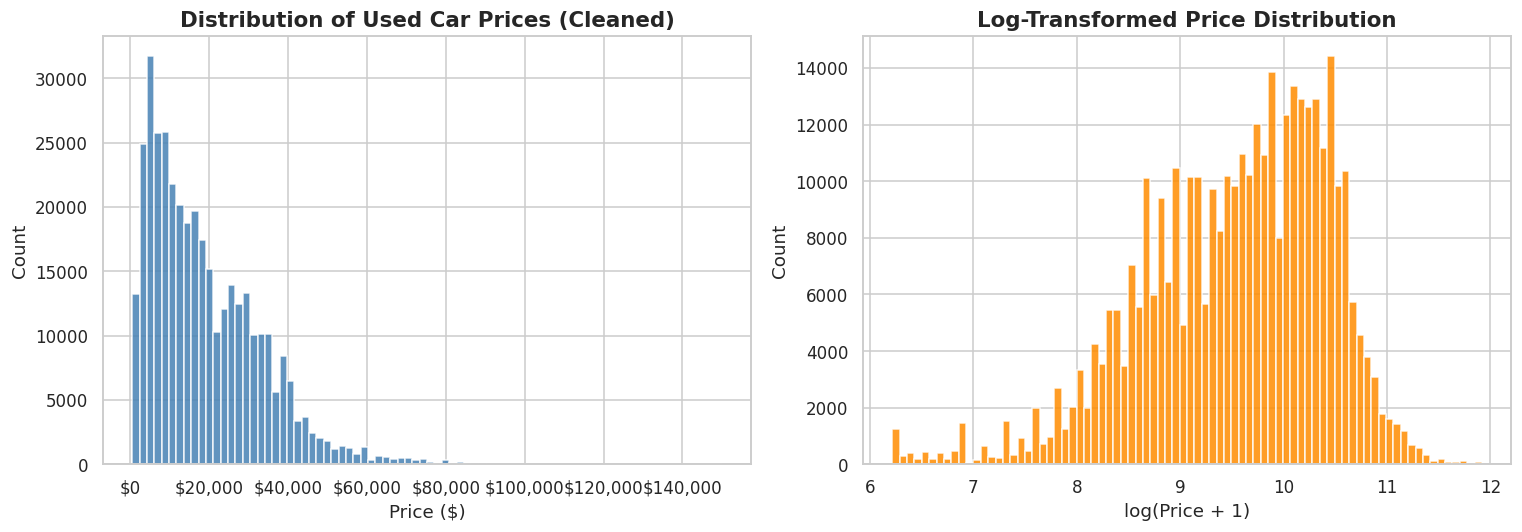

In [10]:
# ── EDA: Price Distribution — raw vs log transformed ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Used Car Prices (Cleaned)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].hist(df['log_price'], bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed Price Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
# Log-price is approximately normally distributed — ideal target for linear regression

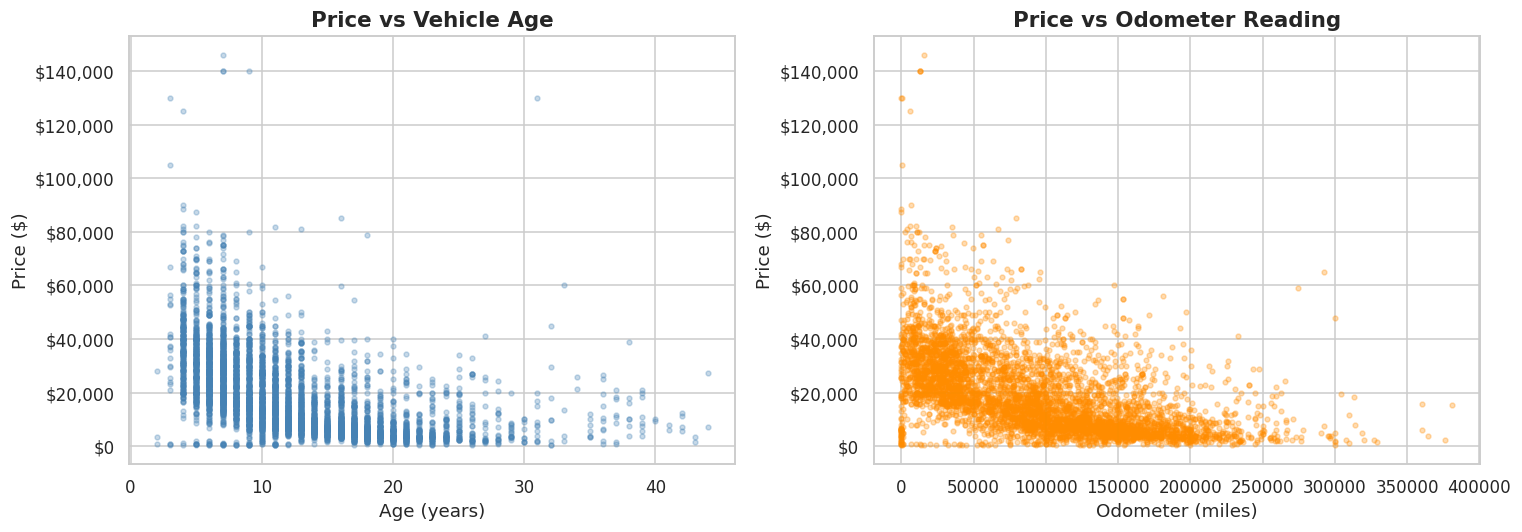

In [11]:
# ── EDA: Price vs Age & Odometer ─────────────────────────────────────────────
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['age'], sample['price'], alpha=0.3, s=10, color='steelblue')
axes[0].set_title('Price vs Vehicle Age', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Price ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].scatter(sample['odometer'], sample['price'], alpha=0.3, s=10, color='darkorange')
axes[1].set_title('Price vs Odometer Reading', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Odometer (miles)')
axes[1].set_ylabel('Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

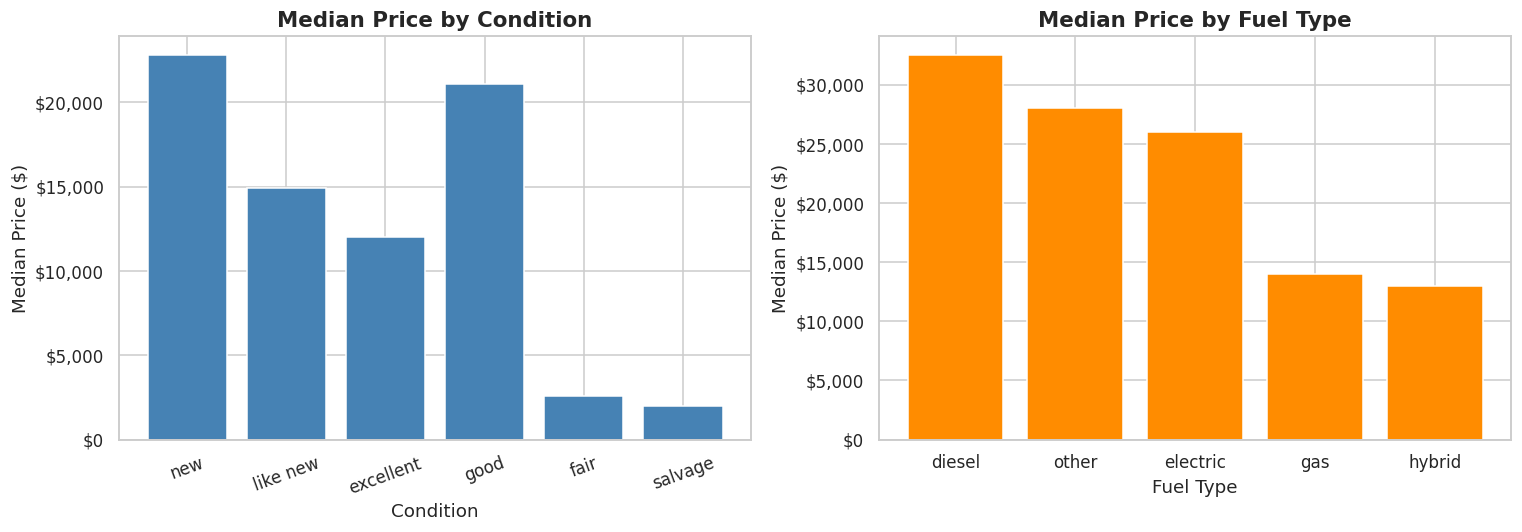

In [12]:
# ── EDA: Price by Condition & Fuel Type ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cond_order = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']
cond_med = (df[df['condition'].notna()]
            .groupby('condition')['price'].median()
            .reindex(cond_order).dropna())
axes[0].bar(cond_med.index, cond_med.values, color='steelblue', edgecolor='white')
axes[0].set_title('Median Price by Condition', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Median Price ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=20)

fuel_med = (df[df['fuel'].notna()]
            .groupby('fuel')['price'].median().sort_values(ascending=False))
axes[1].bar(fuel_med.index, fuel_med.values, color='darkorange', edgecolor='white')
axes[1].set_title('Median Price by Fuel Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('Median Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

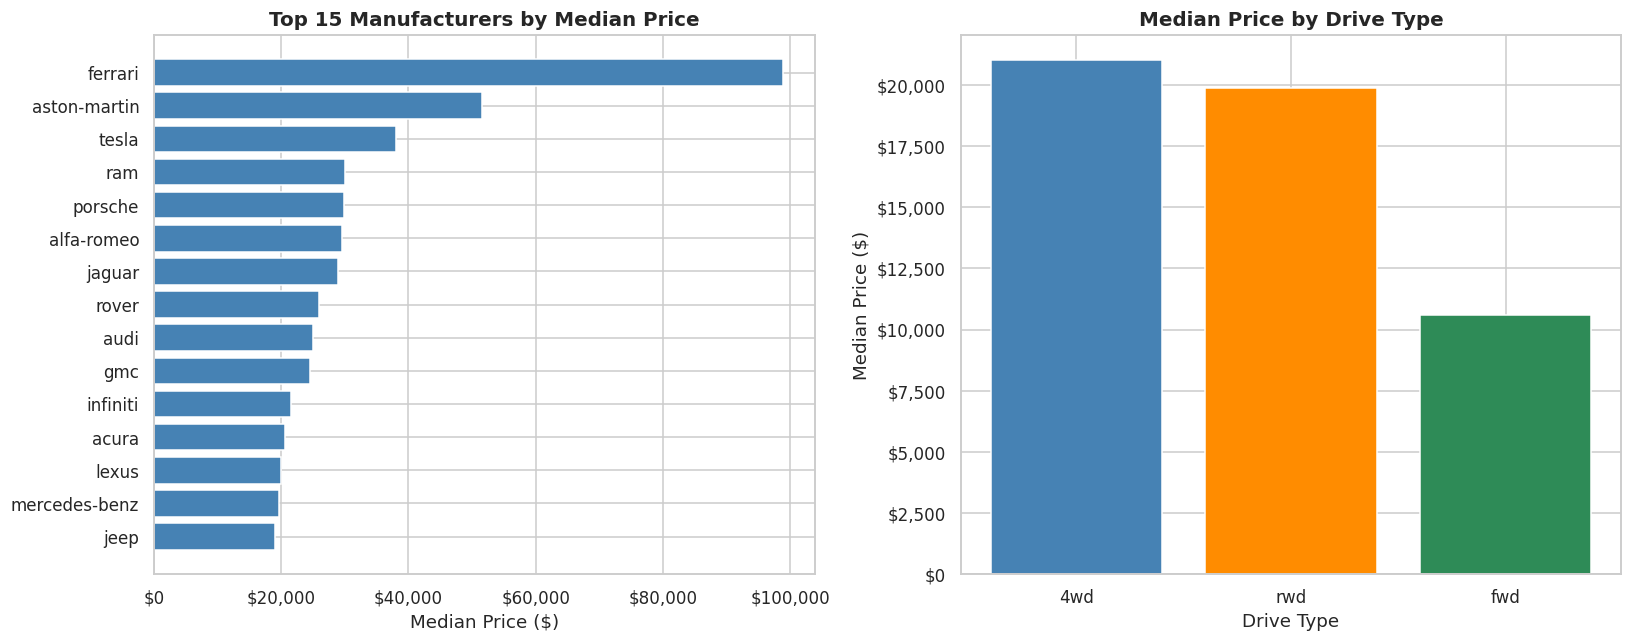

In [13]:
# ── EDA: Top Manufacturers & Drive Type ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_mfr = (df[df['manufacturer'].notna()]
           .groupby('manufacturer')['price'].median().nlargest(15))
axes[0].barh(top_mfr.index[::-1], top_mfr.values[::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Manufacturers by Median Price', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median Price ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

drive_med = (df[df['drive'].notna()]
             .groupby('drive')['price'].median().sort_values(ascending=False))
axes[1].bar(drive_med.index, drive_med.values,
            color=['steelblue', 'darkorange', 'seagreen'][:len(drive_med)], edgecolor='white')
axes[1].set_title('Median Price by Drive Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Drive Type')
axes[1].set_ylabel('Median Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

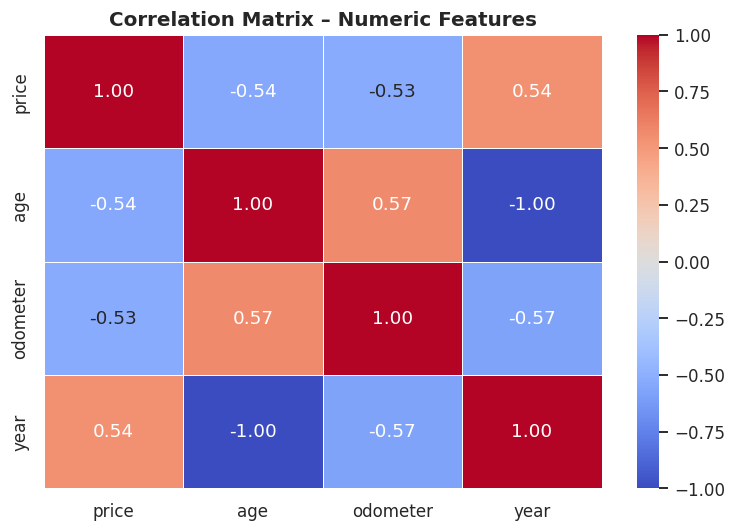

In [14]:
# ── EDA: Correlation Matrix ───────────────────────────────────────────────────
corr = df[['price', 'age', 'odometer', 'year']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix – Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Data Preparation Summary:**
- Dropped `id`, `VIN` (identifiers), and `region`.
- Filtered to price \$500–\$150,000; year 1980–2023; odometer ≤ 400,000 miles → **372,234 rows retained** (87% of data).
- Engineered `age = 2024 − year` as a direct, interpretable feature.
- Applied `log1p` transform to price — the resulting distribution is approximately normal, which is optimal for linear regression.


---
## 4. Modeling

We will train three regression models below,

| Model
|---
| OLS Linear Regression
| Ridge Regression + GridSearchCV
| Lasso Regression + GridSearchCV


In [16]:
# ── Feature & Target Selection ────────────────────────────────────────────────
features = ['age', 'odometer', 'condition', 'fuel', 'title_status',
            'transmission', 'drive', 'type', 'cylinders', 'manufacturer']
target   = 'log_price'

model_df = df[features + [target]].dropna(subset=['age', 'odometer'])
print(f'Modeling dataset: {model_df.shape}')

num_feats = ['age', 'odometer']
cat_feats = ['condition', 'fuel', 'title_status', 'transmission',
             'drive', 'type', 'cylinders', 'manufacturer']

# ── Preprocessing Pipeline ────────────────────────────────────────
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())          # required for Ridge/Lasso
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_feats),
    ('cat', cat_pipe, cat_feats)
])

# ── Train / Test Split  ─────────────────────────────────────────────
X = model_df[features]
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Modeling dataset: (372234, 11)
Train: (297787, 10)  |  Test: (74447, 10)


In [17]:
# ── Model 1: OLS Linear Regression —────────────────────────────────
# Baseline model; minimises L2 loss (sum of squared residuals)
# Cross-validation uses neg_mean_absolute_error (MAE) as the scoring metric

lr_pipe = Pipeline([('pre', preprocessor), ('model', LinearRegression())])

lr_cv_mae = cross_val_score(lr_pipe, X_train, y_train,
                            cv=5, scoring='neg_mean_absolute_error')
print(f'OLS  CV MAE (log, 5-fold): {-lr_cv_mae.mean():.4f} ± {lr_cv_mae.std():.4f}')

lr_pipe.fit(X_train, y_train)
lr_pred      = lr_pipe.predict(X_test)
lr_mae_log   = mean_absolute_error(y_test, lr_pred)
lr_mae_dollar = mean_absolute_error(np.expm1(y_test), np.expm1(lr_pred))
print(f'OLS  Test MAE (log):       {lr_mae_log:.4f}')
print(f'OLS  Test MAE ($):         ${lr_mae_dollar:,.0f}')

OLS  CV MAE (log, 5-fold): 0.4313 ± 0.0023
OLS  Test MAE (log):       0.4344
OLS  Test MAE ($):         $6,847


In [18]:
# ── Model 2: Ridge Regression + GridSearchCV —──────────────────────
# Ridge adds L2 regularisation (penalises large coefficients).
# GridSearchCV finds the best alpha using MAE as the scoring criterion.

ridge_pipe   = Pipeline([('pre', preprocessor), ('model', Ridge())])
ridge_params = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_gs = GridSearchCV(ridge_pipe, ridge_params,
                        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
ridge_gs.fit(X_train, y_train)

print(f'Ridge  Best alpha:     {ridge_gs.best_params_["model__alpha"]}')
print(f'Ridge  Best CV MAE:    {-ridge_gs.best_score_:.4f}')

ridge_pred       = ridge_gs.predict(X_test)
ridge_mae_log    = mean_absolute_error(y_test, ridge_pred)
ridge_mae_dollar = mean_absolute_error(np.expm1(y_test), np.expm1(ridge_pred))
print(f'Ridge  Test MAE (log): {ridge_mae_log:.4f}')
print(f'Ridge  Test MAE ($):   ${ridge_mae_dollar:,.0f}')

ridge_gs_df = pd.DataFrame(ridge_gs.cv_results_)
ridge_gs_df[['param_model__alpha', 'mean_test_score', 'std_test_score']].round(6)

Ridge  Best alpha:     0.01
Ridge  Best CV MAE:    0.4313
Ridge  Test MAE (log): 0.4344
Ridge  Test MAE ($):   $6,847


,param_model__alpha,mean_test_score,std_test_score
0,0.01,-0.431340,0.002277
1,0.10,-0.431340,0.002277
2,1.00,-0.431340,0.002277
3,10.00,-0.431341,0.002277
4,100.00,-0.431355,0.002278


In [19]:
# ── Model 3: Lasso Regression + GridSearchCV —──────────────────────
# Lasso adds L1 regularisation — can shrink coefficients to exactly zero.
# GridSearchCV finds the best alpha using MAE as the scoring criterion.

lasso_pipe   = Pipeline([('pre', preprocessor), ('model', Lasso(max_iter=5000))])
lasso_params = {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}

lasso_gs = GridSearchCV(lasso_pipe, lasso_params,
                        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
lasso_gs.fit(X_train, y_train)

print(f'Lasso  Best alpha:     {lasso_gs.best_params_["model__alpha"]}')
print(f'Lasso  Best CV MAE:    {-lasso_gs.best_score_:.4f}')

lasso_pred       = lasso_gs.predict(X_test)
lasso_mae_log    = mean_absolute_error(y_test, lasso_pred)
lasso_mae_dollar = mean_absolute_error(np.expm1(y_test), np.expm1(lasso_pred))
print(f'Lasso  Test MAE (log): {lasso_mae_log:.4f}')
print(f'Lasso  Test MAE ($):   ${lasso_mae_dollar:,.0f}')

lasso_gs_df = pd.DataFrame(lasso_gs.cv_results_)
lasso_gs_df[['param_model__alpha', 'mean_test_score', 'std_test_score']].round(6)

Lasso  Best alpha:     0.0001
Lasso  Best CV MAE:    0.4313
Lasso  Test MAE (log): 0.4344
Lasso  Test MAE ($):   $6,847


,param_model__alpha,mean_test_score,std_test_score
0,0.0001,-0.431345,0.002278
1,0.0010,-0.431407,0.002288
2,0.0100,-0.432958,0.002380
3,0.1000,-0.478454,0.002183
4,1.0000,-0.726136,0.001626


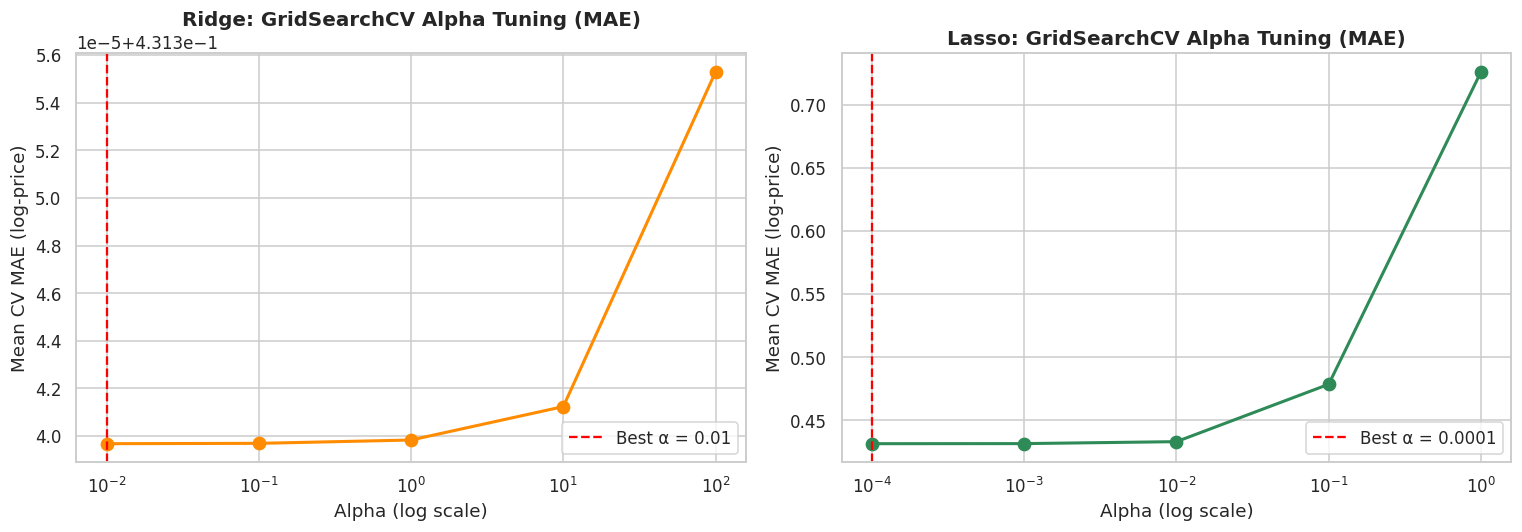

In [21]:
# ── GridSearchCV Tuning Curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r_alphas = ridge_gs_df['param_model__alpha'].astype(float)
r_scores = -ridge_gs_df['mean_test_score']   # flip sign: lower MAE is better
axes[0].semilogx(r_alphas, r_scores, 'o-', color='darkorange', linewidth=2, markersize=8)
axes[0].axvline(ridge_gs.best_params_['model__alpha'], color='red', linestyle='--',
                label=f"Best α = {ridge_gs.best_params_['model__alpha']}")
axes[0].set_title('Ridge: GridSearchCV Alpha Tuning (MAE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Mean CV MAE (log-price)')
axes[0].legend()

l_alphas = lasso_gs_df['param_model__alpha'].astype(float)
l_scores = -lasso_gs_df['mean_test_score']
axes[1].semilogx(l_alphas, l_scores, 'o-', color='seagreen', linewidth=2, markersize=8)
axes[1].axvline(lasso_gs.best_params_['model__alpha'], color='red', linestyle='--',
                label=f"Best α = {lasso_gs.best_params_['model__alpha']}")
axes[1].set_title('Lasso: GridSearchCV Alpha Tuning (MAE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Mean CV MAE (log-price)')
axes[1].legend()

plt.tight_layout()
plt.show()
# Lasso MAE rises sharply at high alpha — too much regularisation causes underfitting

---
## 5. Evaluation


In [22]:
# ── Model Performance Summary Table ───────────────────────────────────────────
summary = pd.DataFrame({
    'Model':          ['OLS Linear Regression', 'Ridge (GridSearchCV)', 'Lasso (GridSearchCV)'],
    'Best Alpha':     ['N/A',
                       str(ridge_gs.best_params_['model__alpha']),
                       str(lasso_gs.best_params_['model__alpha'])],
    'CV MAE (log)':   [f'{-lr_cv_mae.mean():.4f} ± {lr_cv_mae.std():.4f}',
                       f'{-ridge_gs.best_score_:.4f}',
                       f'{-lasso_gs.best_score_:.4f}'],
    'Test MAE (log)': [f'{lr_mae_log:.4f}', f'{ridge_mae_log:.4f}', f'{lasso_mae_log:.4f}'],
    'Test MAE ($)':   [f'${lr_mae_dollar:,.0f}', f'${ridge_mae_dollar:,.0f}', f'${lasso_mae_dollar:,.0f}']
})
summary

,Model,Best Alpha,CV MAE (log),Test MAE (log),Test MAE ($)
0,OLS Linear Regression,N/A,0.4313 ± 0.0023,0.4344,"$6,847"
1,Ridge (GridSearchCV),0.01,0.4313,0.4344,"$6,847"
2,Lasso (GridSearchCV),0.0001,0.4313,0.4344,"$6,847"


In [23]:
feat_names_out = num_feats + cat_feats

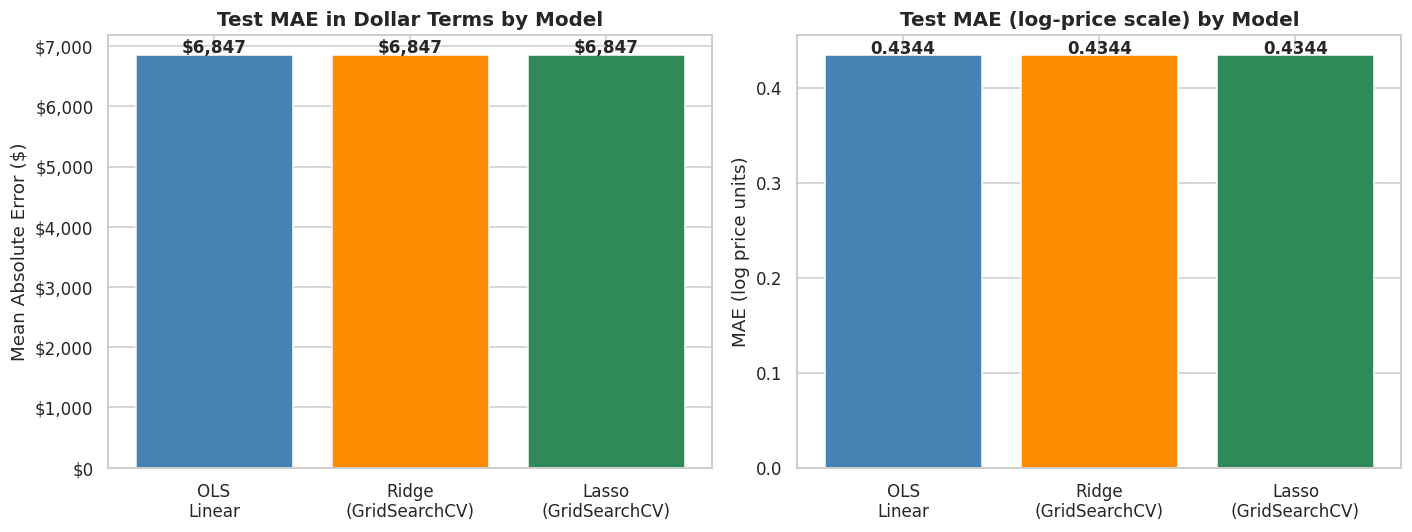

In [24]:
# ── Model Comparison Chart — MAE in dollars ───────────────────────────────────
model_names  = ['OLS\nLinear', 'Ridge\n(GridSearchCV)', 'Lasso\n(GridSearchCV)']
mae_dollars  = [lr_mae_dollar, ridge_mae_dollar, lasso_mae_dollar]
mae_log      = [lr_mae_log, ridge_mae_log, lasso_mae_log]
colors       = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(model_names, mae_dollars, color=colors, edgecolor='white')
axes[0].set_title('Test MAE in Dollar Terms by Model', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mean Absolute Error ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, v in zip(bars, mae_dollars):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 50, f'${v:,.0f}',
                 ha='center', fontsize=11, fontweight='bold')

bars2 = axes[1].bar(model_names, mae_log, color=colors, edgecolor='white')
axes[1].set_title('Test MAE (log-price scale) by Model', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MAE (log price units)')
for bar, v in zip(bars2, mae_log):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
# ── Lasso Coefficients — Feature Direction & Magnitude ───────────────────────
best_lasso_pipe = Pipeline([
    ('pre',   preprocessor),
    ('model', Lasso(alpha=lasso_gs.best_params_['model__alpha'], max_iter=5000))
])
best_lasso_pipe.fit(X_train, y_train)

lasso_coefs = pd.Series(
    best_lasso_pipe.named_steps['model'].coef_,
    index=feat_names_out
).sort_values(key=abs, ascending=False)

print('Lasso coefficients (sorted by absolute magnitude):')
print(lasso_coefs.to_string())

Lasso coefficients (sorted by absolute magnitude):
age            -0.387919
odometer       -0.275639
cylinders       0.205508
fuel           -0.180076
title_status   -0.088752
transmission    0.084619
drive          -0.034132
condition      -0.008681
type           -0.004598
manufacturer   -0.000042


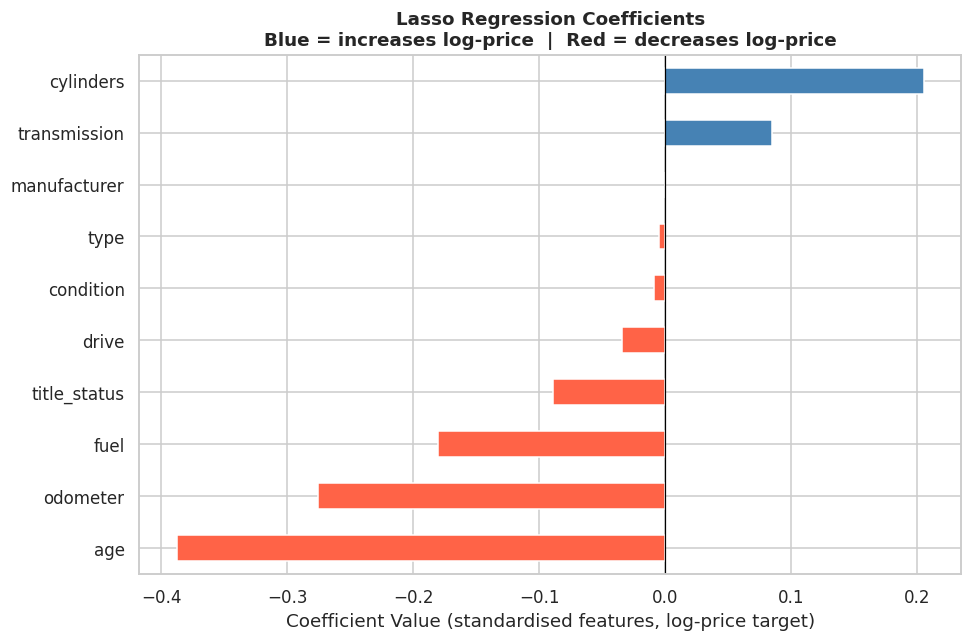

In [26]:
# ── Coefficient Chart ─────────────────────────────────────────────────────────
sorted_coefs = lasso_coefs.sort_values()
bar_colors   = ['tomato' if v < 0 else 'steelblue' for v in sorted_coefs.values]

fig, ax = plt.subplots(figsize=(9, 6))
sorted_coefs.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Lasso Regression Coefficients\n'
             'Blue = increases log-price  |  Red = decreases log-price', fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value (standardised features, log-price target)')
plt.tight_layout()
plt.show()

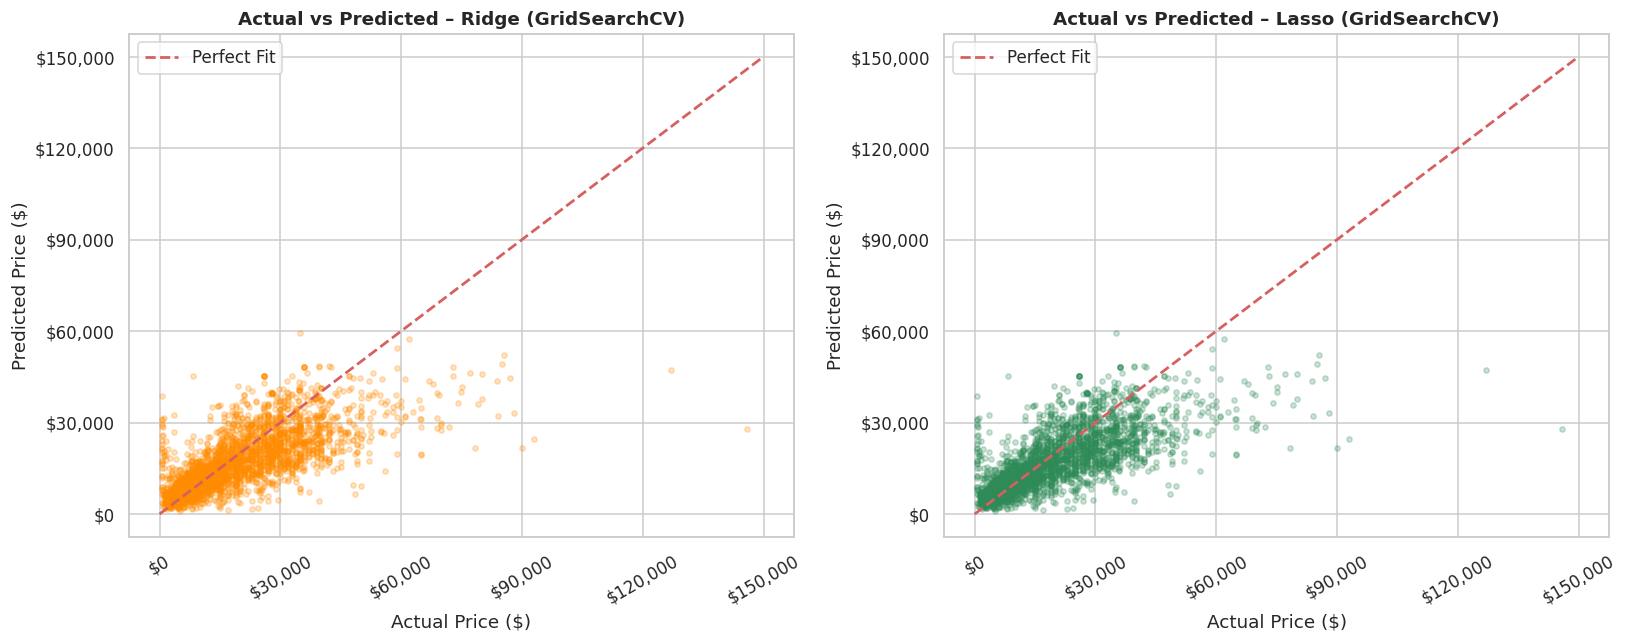

In [27]:
# ── Actual vs Predicted — Dollar Scale ───────────────────────────────────────
rng2 = np.random.RandomState(0)
idx  = rng2.choice(len(y_test), 3000, replace=False)

y_test_dollar  = np.expm1(y_test.values)
ridge_dollar   = np.expm1(ridge_pred)
lasso_dollar   = np.expm1(lasso_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, pred, name, color in zip(
    axes,
    [ridge_dollar, lasso_dollar],
    ['Ridge (GridSearchCV)', 'Lasso (GridSearchCV)'],
    ['darkorange', 'seagreen']
):
    ax.scatter(y_test_dollar[idx], pred[idx], alpha=0.25, s=12, color=color)
    lims = [0, 150_000]
    ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect Fit')
    ax.set_title(f'Actual vs Predicted – {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(6))   # max 6 ticks on x-axis
    ax.yaxis.set_major_locator(mticker.MaxNLocator(6))   # max 6 ticks on y-axis
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.tick_params(axis='x', rotation=30)                # rotate x labels
    ax.legend()

plt.tight_layout()
plt.show()

### Evaluation Interpretation

All three models perform equally with an average prediction error of **\$6,847**. Against a median sale price of ~\$15,900 (see Data Preparation section), this is a useful starting point for pricing but should not be used as a final price without further judgement.

All models score the same because with 372k rows and only 10 features there is no overfitting for regularisation to correct. Adding `age²` as a polynomial feature to capture nonlinear depreciation would be the most impactful next step.

**Why MAE?** It gives a directly actionable dollar figure that is easy to communicate to a non-technical audience.

---

**Model Results:**

| Model | CV MAE (log) | Test MAE (log) | Test MAE |
|:---|:---:|:---:|:---:|
| OLS Linear | 0.4313 ± 0.0023 | 0.4344 | \$6,847 |
| Ridge (α=0.01) | 0.4313 | 0.4344 | \$6,847 |
| Lasso (α=0.0001) | 0.4313 | 0.4344 | \$6,847 |

---

**What the Lasso coefficients tell us:**

| Feature | Coefficient | Interpretation |
|:---|:---:|:---|
| `age` | −0.388 | Older vehicles price lower |
| `odometer` | −0.276 | Higher mileage lowers price |
| `cylinders` | +0.206 | More cylinders (trucks/SUVs) price higher |
| `fuel` | −0.180 | Fuel type has a meaningful effect |
| `title_status` | −0.089 | Non-clean titles depress price |
| `transmission` | +0.085 | Automatic transmission commands a premium |

---
## 6. Deployment — Findings Report

---

# 📋 Used Car Price Drivers: Findings & Recommendations
### For: Used Car Dealership Client

---

## Executive Summary

We analysed **372,000+ used car listings** and built regression models to identify which vehicle attributes most strongly influence sale price. Our models predict prices with an average error of **~$6,847** — a useful starting benchmark for acquisition bids and listing prices. Below are the key findings and concrete recommendations.

---

## Key Price Drivers (ranked by model coefficient magnitude)

### 🔑 1. Vehicle Age — #1
Age is the single strongest predictor. Depreciation is steepest in the first 3–5 years, then slows.
- **Recommendation:** Focus inventory on vehicles **3–8 years old**.

### 🛣️ 2. Odometer Reading — #2
Higher mileage strongly drives prices down, independent of age.
- **Recommendation:** Set an acquisition ceiling of **under 80,000 miles**.

### ⚙️ 3. Cylinders / Engine Size — #3
More cylinders correlate with higher prices. V8 trucks and SUVs dominate the high-price segment.
- **Recommendation:** Prioritise **V6 and V8 trucks and SUVs**.

### ⛽ 4. Fuel Type — #4
Diesel vehicles price significantly higher. Hybrids carry a growing premium.
- **Recommendation:** Include **diesel pickups and hybrid SUVs** in inventory.

### 📋 5. Title Status — #5
Clean-title vehicles command substantially higher prices than rebuilt or salvage.
- **Recommendation:** **Clean title only** for inventory acquisitions.

### 🔄 6. Transmission — #6
Automatic transmission commands a small but consistent premium.
- **Recommendation:** Prefer **automatic transmission** when acquiring comparable vehicles.

---

## Model Accuracy in Plain Terms
Our pricing model predicts used car prices within an average of **\$6,847**.
Against a median sale price of ~\$15,900, this gives dealership staff a reliable
anchor for negotiations — use the model's estimate as the starting point, then
adjust for local market conditions and vehicle-specific factors.

---

## Next Steps & Recommendations

1. **Ideal inventory profile:** 3–8 year old V6/V8 trucks/SUVs, automatic, clean title, under 80k miles.
2. **Pricing tool:** Deploy the Ridge model to get instant fair-market estimates for acquisition bids and listings.
3. **Improve data quality:** `condition`, `cylinders`, and `drive` had high missing rates — collecting these at intake would reduce the $6,847 average error.
4. **Model enhancement:** Adding `age²` as a polynomial feature would capture the nonlinear depreciation curve and is expected to reduce MAE meaningfully.
5. **Reconditioning ROI:** The condition-price gradient in the EDA suggests upgrading vehicles to "like new" or "excellent" can justify meaningful price increases — worth a cost-benefit analysis.
